In [1]:
from IPython.core.magic import register_cell_magic
@register_cell_magic
def skip(line, cell):
    return

import matplotlib as mpl
from working_peaks import *
from peak_modeling_old import peaks_model_C25_fromTf
plt.close('all')
plt.ion()
%matplotlib ipympl

In [ ]:
key = 'fid_au=2_u1=100'
nuobs, Tobs, env = obs_arrays(key, lognu_max=0.7)
nub = nuobs/env.nu0
Tb = (Tobs - env.Ts)/env.T0
colors = ['r', 'b', 'k']
names = ['RS', 'FS', 'RS+FS']


In [ ]:
nF_arr = get_flux_separated(Tobs, nuobs, key)
nF_int_arr = np.array([
  np.trapezoid(nF, Tb, axis=0) for nF in nF_arr
])
nF_int_arr = [*nF_int_arr, nF_int_arr.sum(axis=0)]

fig, ax = plt.subplots()
ax.set_xlabel(nu_label, fontsize=12)
ax.set_ylabel('$\\int \\nu F_\\nu {\\rm d}T/\\nu_0 F_0 T_0$', fontsize=12)
for nFint, col, name in zip(nF_int_arr, colors, names):
  ax.loglog(nub, nFint, c=col, label=name)
ax.legend()
ax.tick_params(axis='x', which='both', labelbottom=False)
ax.tick_params(axis='y', which='both', labelleft=False)
ax.set_title('Time-integrated spectrum', fontsize=12)
fig.tight_layout()
plt.savefig('tint_sp.png', dpi=300)

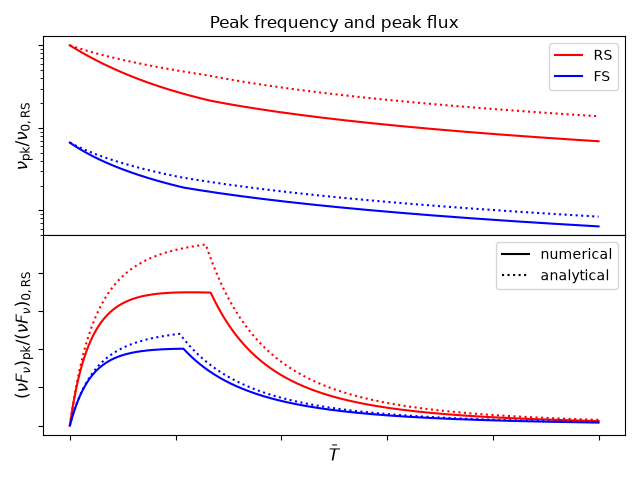

In [33]:
fig, (ax0, ax1) = plt.subplots(2, 1, sharex=True, gridspec_kw = {'hspace':0})
for z, col in zip([4, 1], ['r', 'b']):
  T = normalize_time(Tobs, z, env)
  Tb = T-1
  au, tau, reverse = get_model_params(key, z)
  ratio_T, ratio_nu, ratio_F = ratios_RSvFS_from_au(au)
  npk_C25, nFpk_C25 = C25_peak_model(T, au, tau, reverse)
  npk_R24, nFpk_R24 = R24_peak_model(T, au, tau, reverse)
  if z==1:
    Tb /= ratio_T
    npk_C25 /= ratio_nu
    npk_R24 /= ratio_nu
    nFpk_C25 /= (ratio_nu*ratio_F)
    nFpk_R24 /= (ratio_nu*ratio_F)
  ax0.semilogy(Tb, npk_C25, c=col)
  ax0.semilogy(Tb, npk_R24, c=col, ls=':')
  ax1.plot(Tb, nFpk_C25, c=col)
  ax1.plot(Tb, nFpk_R24, c=col, ls=':')
ax1.tick_params(axis='x', which='both', labelbottom=False)
ax0.tick_params(axis='y', which='both', labelleft=False)
ax1.tick_params(axis='y', which='both', labelleft=False)
ax0.set_ylabel('$\\nu_{\\rm pk}/\\nu_{\\rm 0,RS}$', fontsize=12)
ax1.set_ylabel('$(\\nu F_\\nu)_{\\rm pk}/(\\nu F_\\nu)_{\\rm 0,RS}$', fontsize=12)
ax1.set_xlabel('$\\bar{T}$', fontsize=12)
create_legend_colors(ax0, ['RS', 'FS'], ['r', 'b'])
create_legend_styles(ax1, ['numerical', 'analytical'], ['-', ':'])
ax0.set_title('Peak frequency and peak flux', fontsize=12)
fig.tight_layout()
plt.savefig('example_pks.png', dpi=300)

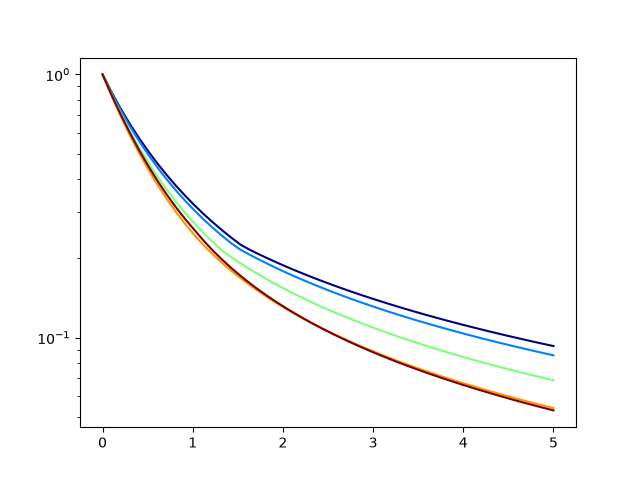

In [37]:
au_arr = 1 + 10.**np.array([-1, -0.5, 0, 0.5, 1])
T = np.linspace(0, 5)
tau = 1

N = len(au_arr)
colors = plt.cm.jet(np.linspace(0,1,N))
fig, ax = plt.subplots()
for i, au in enumerate(au_arr):
  npk, _ = C25_peak_model(1+T, au, tau, reverse=True)
  ax.semilogy(T, npk, c=colors[i])

In [ ]:
tau = 1
reverse = True
logau_arr = np.linspace(-1, 1.5)
au_arr = 1 + 10**logau_arr
Tf_arr, xf_arr = [], []
for au in au_arr:
  popts = fitparams_from_au(au, reverse)
  Tf, xf = compute_Tf(tau, au, popts[0], reverse)
  Tf_arr.append(Tf)
  xf_arr.append(xf)

plt.figure()
plt.plot(logau_arr, xf_arr, label='$x_f$')
plt.plot(logau_arr, Tf_arr, label='$\\tilde{T}_f$')
plt.legend()

Write functions in working_file, execute them here

In [ ]:
#logau_arr = [-1, 0, 1, 1.5]
#tau_arr = [0.5, 1, 2]
logau_arr = np.linspace(-1, 1.5, 100)
tau_arr = np.linspace(0.5, 2, 100)
nub = np.logspace(-2, 1, 500)
ratio_arr = np.zeros((len(logau_arr), len(tau_arr)))
for i, logau in enumerate(logau_arr):
  for j, tau in enumerate(tau_arr):
    au = 1 + 10.**logau
    try:
      nF, nf = compute_tint_and_atpkflux(nub, au, tau, reverse=True)
    except Exception as e:
      print(f"FAIL logau={logau:.3f} tau={tau:.3f}: {e!r}")
      continue
    nu_atpk = nub[np.argmax(nF)]
    nu_tint = nub[np.argmax(nf)]
    ratio_arr[i,j] = nu_atpk/nu_tint

cmap = plt.colormaps['viridis']
norm = plt.Normalize(vmin=ratio_arr.min(), vmax=ratio_arr.max())
fig, ax = plt.subplots()
im = ax.pcolormesh(logau_arr, tau_arr, ratio_arr)#, cmap=cmap, norm=norm)
fig.colorbar(im, ax=ax)
ax.set_xlabel('log$(a_u-1)$')
ax.set_ylabel('$t_{\\rm on}/t_{\\rm off}$')
ax.set_title('$\\nu_{\\rm pk}$ at max flux vs $\\nu_{\\rm pk}$ of time-integrated')
fig.tight_layout()

In [ ]:
plt.savefig('tintegvsatpk.png', dpi=300)

In [ ]:
  key = 'fid_au=2_u1=100'
  z = 4
  env = MyEnv(key)
  data = open_rundata(key, z)
  xd = data.x.to_numpy() * c_ / env.R0
  rec  = cellsBehindShock_fromData(data)
  xr = rec.x.to_numpy() * c_ / env.R0

  fig, (ax0, ax1, ax2) = plt.subplots(3, 1, 
    sharex=True, gridspec_kw = {'hspace':0})
  ax0.plot(xd, data.rho, c='r', label='simulation')
  ax0.plot(xr, rec.rho, ls='--', c='k', label='reconstructed')
  ax1.plot(xd, get_variable(data, 'u', env), c='r')
  ax1.plot(xr, get_variable(rec, 'u', env), ls='--', c='k')
  ax2.plot(xd, data.p, c='r')
  ax2.plot(xr, rec.p, ls='--', c='k')
  ax0.set_ylabel('$\\rho/\\rho_{\\rm norm}$')
  ax1.set_ylabel('$\\Gamma\\beta$')
  ax2.set_ylabel('$p/\\rho_{\\rm norm}c^2$')
  ax2.set_xlabel('$R/R_0$')
  ax0.legend()
  fig.tight_layout()
  plt.savefig('reconstructed.png', dpi=300)

In [ ]:
logau_arr = [-0.5, 0, 0.5]


In [ ]:
%%skip
compare_early_both(logau_arr,'lfac', 'lfac0', linestyles=['--', '-', '-.'])
plt.ylabel('$\\Gamma/\\Gamma_0$')
plt.tight_layout()
plt.savefig('gma_withau.png', dpi=300)

In [ ]:
%%skip
def compare_peaks(logau_arr, z, linestyles = ['--', '-', '-.'], Tf=None, Tmax_in=20):
  '''
  Compare peaks of sims in keys array with varying values of scalename
  '''

  front = 'FS' if z==1 else 'RS'
  title = 'Peak of $(\\nu F_\\nu)_{\\rm ' + front + '}$'
  
  # values
  if Tf is not None:
    Tmax = min(3*Tf, Tmax_in)
  else:
    Tmax = Tmax_in
  tT_arr, nupks_arr, nFpks_arr = [], [], []
  for key in keys:
    tT, nupk_data, nFpk_data = get_peaks_data(key, z, withT=True, Tf=Tf, Tmax=Tmax)
    tT_arr.append(tT)
    nupks_arr.append(nupk_data)
    nFpks_arr.append(nFpk_data)
  
  # plot
  fig, axs = plt.subplots(2, 1, sharex=True)
  for i, (tT, nupks, nFpks, ls) in enumerate(zip(tT_arr, nupks_arr, nFpks_arr, linestyles)):
    axs[0].semilogy(tT, nupks, ls=ls, c='r')
    axs[1].plot(tT, nFpks, ls=ls, c='r')
  axs[0].set_ylabel(nupk_label)
  axs[1].set_ylabel(nFpk_label)
  axs[1].set_xlabel(T_label)

  ax = axs[0]
  ax.set_title(title)
  create_legend_styles(ax, logau_arr, linestyles, title='log$_{10}(a_u-1)$', loc='upper right')
  fig.tight_layout()

In [ ]:
%%skip
keys = [logau_to_key(log_au) for log_au in logau_arr]
compare_peaks(keys, 4, Tf=2.5)
fig = plt.gcf()
axs = fig.get_axes()
axs[0].set_title('Peak of $(\\nu F_\\nu)_{\\rm RS}$')
plt.savefig('pks_withau.png', dpi=300)

In [ ]:
%%skip
key = logau_to_key(0)
compare_model_data(key, 4)
plt.savefig('fitting_exemple.png', dpi=300)

In [ ]:
%%skip
test_fitting('Last', 4, Tmax=6)
plt.savefig('test_fit.png', dpi=300)

In [ ]:
Tf = 100
T = np.linspace(1, 1.5*Tf, 100)
au = 1 + 10**1.5
d_tol=1e-2
nupk, nFpk = peaks_model_C25_fromTf(T, au, Tf, reverse=False)
i_max = np.argmax(nFpk)
slope = np.gradient(nFpk, T)
i_slope = np.where(slope<=d_tol)[0][0]
imax = min(i_slope, i_max)
plt.figure()
plt.loglog(T, nFpk)
plt.twinx()
plt.loglog(T, np.gradient(nFpk, T), c='k')
plt.axhline(0, ls=':', c='k')
plt.axvline(T[i_max], ls=':', c='k')
plt.axvline(T[i_slope], ls=':', c='darkred')

In [ ]:
#logau_arr = [-1, -0.7, -0.4, -0.1, 0.2, 0.5, 0.8, 1.1, 1.4]
logau_arr = np.arange(-1, 1.6, 0.1)

In [ ]:
%%skip
Tf_arr, nupks_arr_RS, nfpks_arr_RS = compute_pks_tintegrated(logau_arr, 4)
Tf_arr, nupks_arr_FS, nfpks_arr_FS = compute_pks_tintegrated(logau_arr, 1)
filename = 'computed_pks'
pks_RS = np.array([nupks_arr_RS, nfpks_arr_RS])
pks_FS = np.array([nupks_arr_FS, nfpks_arr_FS])
np.savez(filename, pks_RS=pks_RS, pks_FS=pks_FS)

In [ ]:
Tf_max=50
NT=100
# defaults in compute_pks_tintegrated
Tf_arr = np.geomspace(1+1e-4, Tf_max, NT)
filename = 'computed_pks.npz'
loaded = np.load(filename)
nupks_arr_RS, nfpks_arr_RS = loaded['pks_RS']
nupks_arr_FS, nfpks_arr_FS = loaded['pks_FS']

In [ ]:
def find_maxflux(au, z=4, Tf=10, NT=100, d_tol=1e-2):
  '''Finds when flux peak is attained
  '''
  T = np.linspace(1, Tf*2, NT)
  nupk, nFpk = peaks_model_C25_fromTf(T, au, Tf, (z==4))
  i_max = np.argmax(nFpk)
  slope = np.gradient(nFpk, T)
  i_slope = np.where(slope<=d_tol)[0][0]
  imax = min(i_slope, i_max)
  return T[imax], nupk[imax], nFpk[imax]

In [ ]:
['Tf', 't_max'] + [f'ShSt_{s}' for s in ['A', 'x_b', 'alpha', 's']]

In [ ]:
T_arrRS, nupk_pkflux_RS, nFpk_arrRS = np.zeros((3,len(logau_arr)))
for i, log_au in enumerate(logau_arr):
  au = 1 + 10**log_au
  T_arrRS[i], nupk_pkflux_RS[i], nFpk_arrRS[i] = find_maxflux(au, 4)
T_arrFS, nupk_pkflux_FS, nFpk_arrFS = np.zeros((3,len(logau_arr)))
for i, log_au in enumerate(logau_arr):
  au = 1 + 10**log_au
  T_arrFS[i], nupk_pkflux_FS[i], nFpk_arrFS[i] = find_maxflux(au, 1)


In [ ]:

fig, ax = plt.subplots()
ax.plot(logau_arr, T_arrRS, label='$\\tilde{T}_{RS}$')
ax.plot(logau_arr, T_arrFS, label='$\\tilde{T}_{FS}$')
ax.plot(logau_arr, nupk_pkflux_RS, label='$\\nu_{pk, RS}$')
ax.plot(logau_arr, nupk_pkflux_FS, label='$\\nu_{pk, FS}$')
ax.plot(logau_arr, nFpk_arrRS, label='$(\\nu F)_{pk, RS}$')
ax.plot(logau_arr, nFpk_arrFS, label='$(\\nu F)_{pk, FS}$')
fig.legend(loc='center right')

In [ ]:
res_RS = nupks_arr_RS/nupk_pkflux_RS[:, np.newaxis]
res_FS = nupks_arr_FS/nupk_pkflux_FS[:, np.newaxis]

In [ ]:
fig, ax = plt.subplots()
cmap = plt.cm.jet
norm = plt.Normalize(vmin=logau_arr[0], vmax=logau_arr[-1])
colors = cmap(norm(logau_arr))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
for i, pks in enumerate(res_FS):
  ax.loglog(Tf_arr, pks, c=colors[i])
plt.colorbar(sm, ax=ax, label='log $(a_u-1)$')

In [ ]:
fig, ax = plt.subplots()
cmap = plt.cm.jet
norm = plt.Normalize(vmin=logau_arr[0], vmax=logau_arr[-1])
colors = cmap(norm(logau_arr))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
for i, pks in enumerate(res_RS):
  ax.loglog(Tf_arr, pks, c=colors[i])
plt.colorbar(sm, ax=ax, label='log $(a_u-1)$')

In [ ]:
# A, x_b, alpha, beta, s
x = Tf_arr
xmax = 50
p0_RS = [0.7, 1.5, 0.9, 0.4, 1]
p0_FS = [0.7, 1.5, 0.7, 0.4, 1]
bounds = ([0.1, 1.1, 0.1, 0.1, 0.05], [2, 10, 2, 1, 1.5])
popts_RS, popts_FS = [], []
func = smooth_bpl_apy
for pks in nupks_arr_RS:
  popt, _ = curve_fit(func, x[x<=xmax], pks[x<=xmax], p0=p0_RS, bounds=bounds)
  popts_RS.append(popt)
for pks in nupks_arr_FS:
  popt, _ = curve_fit(func, x[x<=xmax], pks[x<=xmax], p0=p0_FS, bounds=bounds)
  popts_FS.append(popt)
A_RS, xb_RS, alpha_RS, b_RS, s_RS = np.array(popts_RS).transpose()
A_FS, xb_FS, alpha_FS, b_FS, s_FS = np.array(popts_FS).transpose()
a_RS = (b_RS - alpha_RS)/(1+xb_RS**(-1/s_RS))
a_FS = (b_FS - alpha_FS)/(1+xb_FS**(-1/s_FS))

In [ ]:
fig, ax = plt.subplots()
cmap = plt.cm.jet
norm = plt.Normalize(vmin=logau_arr[0], vmax=logau_arr[-1])
colors = cmap(norm(logau_arr))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
for i, (pks, popt) in enumerate(zip(nupks_arr_RS, popts_RS)):
  ax.loglog(Tf_arr, pks, c=colors[i])
  #ax.loglog(Tf_arr, smooth_bpl_apy(Tf_arr, *popt), ls='--', c='k')
plt.colorbar(sm, ax=ax, label='log $(a_u-1)$')
ax.set_xlabel('$\\tilde{T}_f$')
ax.set_ylabel(nupk_label)
ax.set_title('Peaks of $(\\nu f_\\nu)_{RS}$')
fig.tight_layout()

In [ ]:
a_arr = np.linspace(-1, -0.5, len(logau_arr))
b = -0.45
def func(x, a, b, K=0.76, xb=3.):
  inf = K*x**a
  sup = K*xb**a*(x/xb)**b
  return np.where(x<=xb, inf, sup)
fig, ax = plt.subplots()
cmap = plt.cm.jet
norm = plt.Normalize(vmin=logau_arr[0], vmax=logau_arr[-1])
colors = cmap(norm(logau_arr))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
for i, (pks, popt) in enumerate(zip(nupks_arr_FS, popts_FS)):
  ax.loglog(Tf_arr, pks, c=colors[i])
  #ax.loglog(Tf_arr, func(Tf_arr, a_arr[i], b), ls='--', c='k')
  #ax.loglog(Tf_arr, smooth_bpl_apy(Tf_arr, *popt), ls='--', c='k')
plt.colorbar(sm, ax=ax, label='log $(a_u-1)$')
ax.set_xlabel('$\\tilde{T}_f$')
ax.set_ylabel(nupk_label)
ax.set_title('Peaks of $(\\nu f_\\nu)_{FS}$')
plt.tight_layout()

In [ ]:
fig, ax = plt.subplots()
cmap = plt.cm.jet
norm = plt.Normalize(vmin=logau_arr[0], vmax=logau_arr[-1])
colors = cmap(norm(logau_arr))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
for i, pks in enumerate(nfpks_arr_RS):
  ax.loglog(Tf_arr, pks, c=colors[i])
  #ax.loglog(Tf_arr, smooth_bpl_apy(Tf_arr, *popt), ls='--', c='k')
plt.colorbar(sm, ax=ax, label='log $(a_u-1)$')
ax.set_xlabel('$\\tilde{T}_f$')
ax.set_ylabel("$(\\nu f_\\nu)_{\\rm pk} / \\nu_0 F_0 T_0$")
ax.set_title('Peaks of $(\\nu f_\\nu)_{RS}$')

In [ ]:
fig, ax = plt.subplots()
cmap = plt.cm.jet
norm = plt.Normalize(vmin=logau_arr[0], vmax=logau_arr[-1])
colors = cmap(norm(logau_arr))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
for i, pks in enumerate(nfpks_arr_FS):
  ax.loglog(Tf_arr, pks, c=colors[i])
  #ax.loglog(Tf_arr, smooth_bpl_apy(Tf_arr, *popt), ls='--', c='k')
plt.colorbar(sm, ax=ax, label='log $(a_u-1)$')
ax.set_xlabel('$\\tilde{T}_f$')
ax.set_ylabel("$(\\nu f_\\nu)_{\\rm pk} / \\nu_0 F_0 T_0$")
ax.set_title('Peaks of $(\\nu f_\\nu)_{FS}$')

In [ ]:
compare_pks_tintegrated(logau_arr, 1)

In [ ]:
log_au = 1.5
key = logau_to_key(log_au)
z = 4
compare_model_data(key, z, direct=False)

In [ ]:
log_au = 1
key = logau_to_key(log_au)
z = 4
compare_lfac_derived(key, z)

In [ ]:
compare_fits_hydro(keys, 4, 'lfac', scalename='chi')

In [ ]:
compare_peaks(keys, 4, scalename='chi')

In [ ]:
compare_fits_hydro(keys, 1, 'lfac', scalename='chi')

In [ ]:
compare_peaks(keys, 1, scalename='chi')

In [ ]:
log_au = 0.
z = 4
#key = logau_to_key(log_au)
key = 'sph_fid'
compare_model_data(key, z)

In [ ]:
log_au = 0.
chi = 0.5
key = f'log_au={log_au:.1f}_chi={chi:.1f}'
#extract_data_thinshell(key, noOut=True, noPrint=True)
plot_fit_hydro_both(key, 'lfac')

In [ ]:
plot_fittedvals('alpha')

In [ ]:
log_au = 1
z = 4
key = logau_to_key(log_au)
compare_lfac_derived(key, z)

In [ ]:
%%skip
# nu' and L'_max slopes
for front in ['RS', 'FS']:
  df = open_sweep(front)
  keys = df.keys()
  nukeys = [key for key in keys if "nu" in key]
  Lkeys = [key for key in keys if "L" in key]
  row = df.loc[df.log_aum==0.]
  popt_nu = row[nukeys].to_numpy()[0]
  popt_L = row[Lkeys].to_numpy()[0]
  nu_alpha = a_from_popt(popt_nu) - 1
  L_alpha = a_from_popt(popt_L) + 1
  print("For front ", front, ":")
  print(f"\t alpha_nu = {nu_alpha:.2f}")
  print(f"\t alpha_L = {L_alpha:.2f}")

Compare peaks with the corresponding fit

- plot comparing peaks from data to peaks from fit
- try fitting a sim with a 'random' $a_u$ to find what's missing
- write what's missing

In [ ]:
%%skip
key, z = 'sph_fid', 1
test_fitting(key, z, fit=True)
popt_sim = get_paramsfit_sim(key)
print(popt_sim)
# it works for a_u!, both RS and FS independantly

Step 1:
compare model of peaks + Band to data
Step 2:
try fitting a dataset

In [ ]:
%%skip
key = 'sph_fid'
nuobs, Tobs, env = obs_arrays(key)
nu = nuobs/env.nu0
T = (Tobs - env.Ts)/env.T0
au, dRRS, dRFS = get_paramsfit_sim('sph_fid')
tT = 1 + T

nupks_RS_R, _ = peaks_model_R24(tT, au, dRRS, reverse=True)
nupks_FS_R, _ = peaks_model_R24(tT, au, dRFS, reverse=False)
nupks_RS_C, _ = peaks_model_C25(tT, au, dRRS, reverse=True)
nupks_FS_C, _ = peaks_model_C25(tT, au, dRFS, reverse=False)

s_RS_R, s_FS_R = get_initslope(tT, nupks_RS_R), get_initslope(tT, nupks_FS_R)
s_RS_C, s_FS_C = get_initslope(tT, nupks_RS_C), get_initslope(tT, nupks_FS_C)

print("Init dlog nupk dlog tT")
print(f"R24, RS = {s_RS_R:.1f}, FS = {s_FS_R:.1f}")
print(f"C25, RS = {s_RS_C:.1f}, FS = {s_FS_C:.1f}")

In [ ]:
%%skip
nuobs, Tobs, env = obs_arrays('sph_fid')
nu_b = nuobs/env.nu0
T = (Tobs - env.Ts)/env.T0
au, dRRS, dRFS = get_paramsfit_sim('sph_fid')
tT = 1 + T
nupks_RS, nFpks_RS = peaks_model_C25(tT, au, dRRS, reverse=True)
F_RS = np.zeros((len(T), len(nu_b)))
for i, (nupk, nFpk) in enumerate(zip(nupks_RS, nFpks_RS)):
  Fpk = nFpk/nupk
  nu = nu_b/nupk
  F = Fpk * Band_func(nu, -0.5, -0.5*env.psyn)
  F_RS[i] = F
lognu=-1
i_nu = find_closest(nu_b, 10**lognu)
plt.figure()
plt.title('$\\nu_{\\rm obs}=0.1\\nu_0$')
plt.plot(T, F_RS[:,i_nu], c='r')
plt.xlabel(T_label)
plt.ylabel(nF_label)
plt.tight_layout()

In [ ]:

key = 'fid_au=2_u1=100'
#key = 'Last'
popt_sim = get_paramsfit_sim(key)
sim_au, sim_tau4, sim_tau1 = popt_sim
print(f'Params from sim: a_u = {sim_au:.2f}, tau_4 = {sim_tau4:.2f}, tau_1 = {sim_tau1:.2f}')
popt_fit = get_fit_fullflux(key)
fit_au, fit_tau1, fit_tau1 = popt_fit
print(f'Params recovered by fitting: a_u = {fit_au:.2f}, tau_4 = {fit_tau1:.2f}, tau_1 = {fit_tau1:.2f}')

nuobs, Tobs, env = obs_arrays(key, lognu_min=-3, lognu_max=1)
nub = nuobs/env.nu0
Tb = (Tobs - env.Ts)/env.T0
# data vs model from sim params vs model from fit params
nF_data = get_flux_data(Tobs, nuobs, key) / env.nu0F0
nF_model_sim = nub * flux_model_C25_normed(Tb, nub, *popt_sim)
nF_model_fit = nub * flux_model_C25_normed(Tb, nub, *popt_fit)


In [ ]:

def compare_sp(logT, ax_in=None, **kwargs):
  i_T = find_closest(Tb, 10**logT)
  
  c0, c1 = 'C0', 'k'
  if ax_in is None:
    fig, ax = plt.subplots()
  else:
    ax = ax_in
    if 'c' in kwargs:
      col = kwargs.get('c')
      c0, c1 = col, col

  ax.loglog(nub, nF_data[i_T], c=c0, label='data')
  ax.loglog(nub, nF_model_sim[i_T], c=c1, ls='--', label='model 1 (sim)')
  ax.loglog(nub, nF_model_fit[i_T], c=c1, ls=':', label='model 2 (fit)')
  ax.set_xlabel(nu_label)
  ax.set_ylabel(nF_label)
  if ax_in is None:
    ax.set_title('log$_{10} \\bar{T}=$' + f'{logT}')
    ax.legend()

def compare_lc(lognu, ax_in=None, **kwargs):
  i_nu = find_closest(nub, 10**lognu)

  c0, c1 = 'C0', 'k'
  if ax_in is None:
    fig, ax = plt.subplots()
  else:
    ax = ax_in
    if 'c' in kwargs:
      col = kwargs.get('c')
      c0, c1 = col, col

  ax.plot(Tb, nF_data[:,i_nu], c=c0, label='data')
  ax.plot(Tb, nF_model_sim[:,i_nu], c=c1, ls='--', label='model 1 (sim)')
  ax.plot(Tb, nF_model_fit[:,i_nu], c=c1, ls=':', label='model 2 (fit)')
  ax.set_xlabel('$\\bar{T}$')
  ax.set_ylabel(nF_label)
  if ax_in is None:
    ax.set_title('log$_{10}\\nu/\\nu_0=$' + f'{lognu}')
    ax.legend()

def plot_spectra(logT_arr):
  fig, ax = plt.subplots()
  N = len(logT_arr)
  colors = plt.cm.jet(np.linspace(0,1,N))
  for logT, col in zip(logT_arr, colors):
    compare_sp(logT, ax_in=ax, c=col)
  legcol = create_legend_colors(ax, [f'{logT:.1f}' for logT in logT_arr], colors,
    title='$\\log_{10}\\bar{T}$', loc='upper right')
  leglst = create_legend_styles(ax, ['data', 'model (sim)', 'model (fit)'], ['-', '--', ':'],
    loc='upper left')
  ax.add_artist(legcol)

def plot_lightcurves(lognu_arr):
  fig, ax = plt.subplots()
  N = len(lognu_arr)
  colors = plt.cm.jet(np.linspace(0,1,N))
  for lognu, col in zip(lognu_arr, colors):
    compare_lc(lognu, ax_in=ax, c=col)
  legcol = create_legend_colors(ax, [f'{lognu:.1f}' for lognu in lognu_arr], colors,
    title='$\\log_{10}\\tilde{\\nu}$', loc='upper right')
  leglst = create_legend_styles(ax, ['data', 'model (sim)', 'model (fit)'], ['-', '--', ':'],
    loc='upper center')
  ax.add_artist(legcol)
  
def plot_flux(var, log_arr):
  if var == 'sp':
    logx, logy = True, True
    leg1_title = '$\\log_{10}\\bar{T}$'
    leg1_loc = 'upper left'
    leg2_loc = 'lower center'
    plotfunc = compare_sp
    title = 'Instantaneous spectra'
  elif var == 'lc':
    logx, logy = False, False
    leg1_title = '$\\log_{10}\\tilde{\\nu}$'
    leg1_loc = 'center right'
    leg2_loc = 'upper right'
    plotfunc = compare_lc
    title = 'Lightcurves'
  else:
    print("Variable 'var' must be 'sp' or 'lc'!")
    return 0.
  #title += ', with $(a_u, \\Delta R_{\\rm RS}/R_0, \\Delta R_{\\rm FS}/R_0)$'

  fig, ax = plt.subplots()
  N = len(log_arr)
  colors = plt.cm.Set1(np.linspace(0,1,N))
  for log, col in zip(log_arr, colors):
    plotfunc(log, ax_in=ax, c=col)
  legcol = create_legend_colors(ax, [f'{log:.1f}' for log in log_arr], colors,
    title=leg1_title, loc=leg1_loc)
  legstr = ['simulation', 'model + sim parameters', 'best fit model']
      #f'sim: ({sim_au:.2f}, {sim_tau4:.2f}, {sim_tau1:.2f})',
      #f'fit: ({fit_au:.2f}, {fit_tau1:.2f}, {fit_tau1:.2f})']
  leglst = create_legend_styles(ax, legstr, ['-', '--', ':'],
    loc=leg2_loc)
  ax.add_artist(legcol)
  ax.set_title(title)
  fig.tight_layout()


In [ ]:
plot_flux('sp', [-0.5, 0, 0.3])
plt.savefig('example_sp.png', dpi=300)

In [ ]:

plot_flux('lc', [-2, -1, 0])
plt.savefig('example_lc.png', dpi=300)

In [ ]:
(0.87-0.9)/0.9

Time-integrated spectra

In [ ]:

logau_arr = np.arange(-1, 1.6, 0.1)
#logau_arr = [-1, -0.5, 0., 0.5, 1]
compare_timeIntegrated_withau(logau_arr, 4, Tf=2.5)

In [ ]:
def compare_timeIntegrated_withTf(Tf_arr, z, lognu_min=-3, lognu_max=1, Nnu=200, log_au=0., Tmax=20):
  '''
  Plot time-integrated spectra for an array of tilde{T}_f values
  '''
  nub = np.logspace(lognu_min, lognu_max, Nnu)
  spectras = compute_timeIntegrated_withTf(Tf_arr, z,
      lognu_min=lognu_min, lognu_max=lognu_max, Nnu=Nnu, log_au=log_au, Tmax=Tmax)
  N = len(Tf_arr)
  fig, ax = plt.subplots()
  cmap = plt.cm.plasma
  norm = plt.Normalize(vmin=Tf_arr[0], vmax=Tf_arr[-1])
  colors = cmap(norm(Tf_arr))
  sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
  plt.colorbar(sm, ax=ax, label='$\\tilde{T}_f$')
  for i, (Tf, f) in enumerate(zip(Tf_arr, spectras)):
    ax.loglog(nub, f, color=colors[i])
  plt.title('Time-integrated spectra with $\\tilde{T}_f$, log$_{10}(a_u-1)='+f'{log_au:.1f}$')
  plt.xlabel(nu_label)
  plt.ylabel(nF_label)

In [ ]:
Tf_arr = np.geomspace(1.2, 10)
compare_timeIntegrated_withTf(Tf_arr, 4)

In [ ]:
z = 1
logau_arr = np.arange(-1, 1.6, 0.1)
lognu_min=-1
lognu_max=0
Nnu=1000
nub = np.logspace(lognu_min, lognu_max, Nnu)
spectras = compute_timeIntegrated_withau(logau_arr, z, lognu_min, lognu_max, Nnu)
pks = np.array([[nub[np.argmax(f)], f.max()] for f in spectras])
nupks, nFpks = pks[:,0], pks[:,1]
fig, ax = plt.subplots()
ax.scatter(logau_arr, nupks, marker='x', label='nu')
ax.set_yscale('log')
ax.tick_params(axis='y', colors='C0', which='both')
ax.set_ylabel(nupk_label, c='C0')
ax2 = ax.twinx()
ax2.scatter(logau_arr, nFpks, marker='+', label='nF', c='C1')
ax2.set_yscale('log')
ax2.tick_params(axis='y', colors='C1', which='both')
ax2.set_ylabel(nFpk_label, c='C1')
ax2.set_xlabel('log$_{10}(a_u-1)$')
front = 'RS' if z == 4 else 'FS'
ax.set_title(f'Peak of $(\\nu f_\\nu)_{{{front}}}$ with $a_u$')
fig.tight_layout()

In [ ]:
lognu_min=-2
lognu_max=0
Nnu=500
Tmax=100
Tf_max = 50
NT=100
z = 1
nub = np.logspace(lognu_min, lognu_max, Nnu)
Tf_arr = np.geomspace(1.+1e-4, Tf_max, NT)
plt.figure()
logau_arr = [-1, -0.7, -0.4, -0.1, 0.2, 0.5, 0.8, 1.1, 1.4]
cmap = plt.cm.jet
norm = plt.Normalize(vmin=logau_arr[0], vmax=logau_arr[-1])
colors = cmap(norm(logau_arr))
for i, log_au in enumerate(logau_arr):
      spectras = compute_timeIntegrated_withTf(Tf_arr, z,
            lognu_min=lognu_min, lognu_max=lognu_max, Nnu=Nnu, log_au=log_au, Tmax=Tmax)
      pks = [nub[np.argmax(f)] for f in spectras]
      plt.loglog(Tf_arr, pks, c=colors[i])#, label=f'{log_au:.1f}')
theoric = 1/(0.805+0.706*Tf_arr)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.loglog(Tf_arr, theoric, ls='--', c='k', label='model R24')
plt.ylabel('$\\nu_{\\rm pk}/\\nu_0$')
plt.xlabel('$\\tilde{T}_f$')
front = 'RS' if z==4 else 'FS'
plt.title(f'Peak of $(\\nu f_\\nu)_{{{front}}}$ with $\\tilde{{T}}_f$')
#plt.legend(title='log $(a_u-1)$', loc='lower left')
ax = plt.gca()
plt.colorbar(sm, ax=ax, label='log $(a_u-1)$')
plt.tight_layout()

In [ ]:
T = np.linspace(1, 5, 1000)
logau_arr = np.linspace(-0.5, 0.5, 20)
T_maxs = []
for log_au in logau_arr:
  au = 10**log_au + 1
  nupks, nFpks = peaks_model_C25_fromTf(T, au, 5, True)
  T_maxF = T[np.argmax(nFpks)]
  T_maxs.append(T_maxF)

plt.figure()
plt.plot(logau_arr, T_maxs)

In [ ]:
au_arr = np.arange(-0.5, 0.6, 0.1)
N = len(au_arr)
colors = plt.cm.plasma(np.linspace(0,1,N))
plt.figure()
for i, log_au in enumerate(au_arr):
  au = 10**log_au + 1
  nupks, nFpks = peaks_model_C25_fromTf(T, au, 10, True)
  plt.plot(T, nFpks, c=colors[i])

In [ ]:
%%skip
def H(au):
  G21, G34 = relLfac_from_au(au)
  b34 = derive_velocity(G34)
  Hau = (G34-1)*G34*b34/(1+au**2)
  return Hau

logau_arr = np.linspace(-0.5, 1)
au_arr = 10**logau_arr + 1
plt.figure()
plt.plot(logau_arr, H(au_arr))

In [ ]:
plt.figure()
logau_arr = np.linspace(-0.5, 1)
g2_arr = [g2_from_au(1+10**logau)[1] for logau in logau_arr]
plt.plot(logau_arr, g2_arr)

In [ ]:
T = np.linspace(1, 10, 100)
logau_arr = np.linspace(-1, 1.5, 20)
slopes = []
for log_au in logau_arr:
  au = 10**log_au + 1
  nupks, nFpks = peaks_model_C25_fromTf(T, au, 10, True)
  s = logslope(T[0], nupks[0], T[10], nupks[10])
  slopes.append(s)
plt.figure()
plt.plot(logau_arr, slopes)